In [1]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patheffects as pe
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

plt.style.use("sty1 copy.mplstyle")

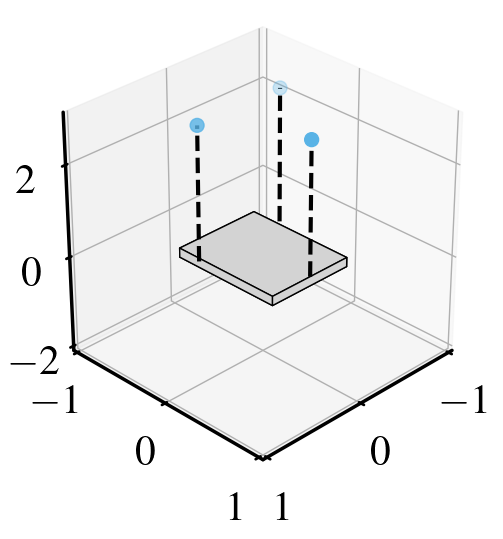

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


class Payload:
    def __init__(self):
        self.params = {"payload_dims": {"x": 0.8, "y": 1.0, "z": 0.2}}


def quads_config(pyld, n, radius):
    # Generate configuration of quadrotors relative to the payload (3D layout)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    rhos_x = radius * np.sin(angles)
    rhos_y = radius * np.cos(angles)
    # Hover at constant height above the payload
    rhos_z = np.full_like(rhos_x, 3.0)
    rhos = np.vstack((rhos_x, rhos_y, rhos_z))
    return {"rhos": rhos}


def plot_quadrotors_3d(n, radius, ax, title, pyld, conf):
    # Define payload boundary (cube)
    payload_x = pyld.params["payload_dims"]["x"]
    payload_y = pyld.params["payload_dims"]["y"]
    payload_z = pyld.params["payload_dims"]["z"]

    cube_vertices = np.array(
        [
            [-payload_x / 2, -payload_y / 2, -payload_z / 2],
            [-payload_x / 2, payload_y / 2, -payload_z / 2],
            [payload_x / 2, payload_y / 2, -payload_z / 2],
            [payload_x / 2, -payload_y / 2, -payload_z / 2],
            [-payload_x / 2, -payload_y / 2, payload_z / 2],
            [-payload_x / 2, payload_y / 2, payload_z / 2],
            [payload_x / 2, payload_y / 2, payload_z / 2],
            [payload_x / 2, -payload_y / 2, payload_z / 2],
        ]
    )

    faces = [
        [cube_vertices[j] for j in [0, 1, 2, 3]],  # Bottom face
        [cube_vertices[j] for j in [4, 5, 6, 7]],  # Top face
        [cube_vertices[j] for j in [0, 1, 5, 4]],  # Side face 1
        [cube_vertices[j] for j in [2, 3, 7, 6]],  # Side face 2
        [cube_vertices[j] for j in [1, 2, 6, 5]],  # Side face 3
        [cube_vertices[j] for j in [0, 3, 7, 4]],  # Side face 4
    ]

    ax.add_collection3d(
        Poly3DCollection(
            faces,
            facecolors="lightgray",
            linewidths=1,
            edgecolors="black",
            alpha=1,
            zorder=1,
        )
    )

    ax.scatter(
        conf["rhos"][0],
        conf["rhos"][1],
        conf["rhos"][2],
        s=100,
        label="Quadrotors",
        zorder=2,
    )

    top_center_z = payload_z / 2
    for x, y, z in zip(conf["rhos"][0], conf["rhos"][1], conf["rhos"][2]):
        ax.plot3D(
            [x, x], [y, y], [top_center_z, z], color="black", linestyle="--", zorder=3
        )

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-2, 3)
    ax.set_box_aspect([1, 1, 1])


pyld = Payload()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

n = 3
radius = 0.5

conf = quads_config(pyld, n, radius)

plot_quadrotors_3d(n, radius, ax, f"{n}-Quadrotors", pyld, conf)
ax.view_init(elev=30, azim=45)

fig.savefig("../figures/3_quads.pdf", format="pdf", dpi=300)
plt.show()

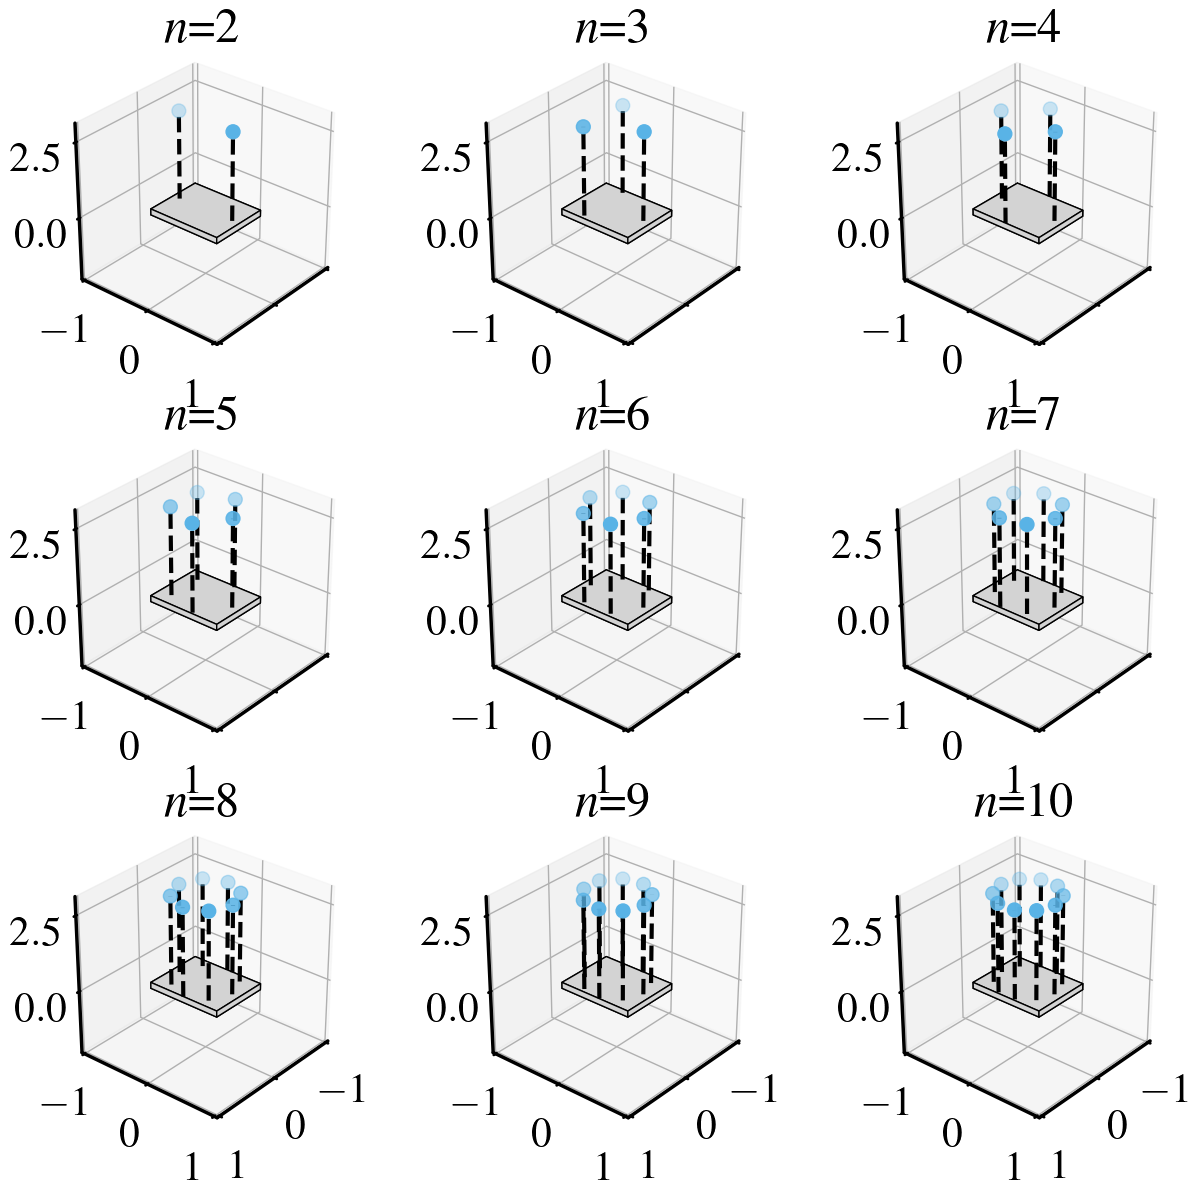

In [28]:
class Payload:
    def __init__(self):
        self.params = {"payload_dims": {"x": 0.8, "y": 1, "z": 0.2}}


def quads_config(pyld, n, radius):

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    rhos_x = radius * np.sin(angles)
    rhos_y = radius * np.cos(angles)

    rhos_z = np.full_like(rhos_x, 3.0)
    rhos = np.vstack((rhos_x, rhos_y, rhos_z))
    return {"rhos": rhos}


def plot_quadrotors_3d(n, radius, ax, title, pyld, conf):

    payload_x = pyld.params["payload_dims"]["x"]
    payload_y = pyld.params["payload_dims"]["y"]
    payload_z = pyld.params["payload_dims"]["z"]

    cube_vertices = np.array(
        [
            [-payload_x / 2, -payload_y / 2, -payload_z / 2],
            [-payload_x / 2, payload_y / 2, -payload_z / 2],
            [payload_x / 2, payload_y / 2, -payload_z / 2],
            [payload_x / 2, -payload_y / 2, -payload_z / 2],
            [-payload_x / 2, -payload_y / 2, payload_z / 2],
            [-payload_x / 2, payload_y / 2, payload_z / 2],
            [payload_x / 2, payload_y / 2, payload_z / 2],
            [payload_x / 2, -payload_y / 2, payload_z / 2],
        ]
    )

    faces = [
        [cube_vertices[j] for j in [0, 1, 2, 3]],  # Bottom face
        [cube_vertices[j] for j in [4, 5, 6, 7]],  # Top face
        [cube_vertices[j] for j in [0, 1, 5, 4]],  # Side face 1
        [cube_vertices[j] for j in [2, 3, 7, 6]],  # Side face 2
        [cube_vertices[j] for j in [1, 2, 6, 5]],  # Side face 3
        [cube_vertices[j] for j in [0, 3, 7, 4]],  # Side face 4
    ]

    ax.add_collection3d(
        Poly3DCollection(
            faces,
            facecolors="lightgray",
            linewidths=1,
            edgecolors="black",
            alpha=1,
            zorder=1,
        )
    )

    ax.scatter(
        conf["rhos"][0],
        conf["rhos"][1],
        conf["rhos"][2],
        s=100,
        label="Quadrotors",
        zorder=2,
    )

    top_center_z = payload_z / 2
    for x, y, z in zip(conf["rhos"][0], conf["rhos"][1], conf["rhos"][2]):
        ax.plot3D(
            [x, x], [y, y], [top_center_z, z], color="black", linestyle="--", zorder=3
        )

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-2, 3)

    ax.set_box_aspect([1, 1, 1])
    ax.set_title(f"{title}")


pyld = Payload()
n_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
radius = 0.4

fig, axes = plt.subplots(3, 3, subplot_kw={"projection": "3d"}, sharex=True)

for ax, n in zip(axes.flat, n_values):
    conf = quads_config(pyld, n, radius)
    plot_quadrotors_3d(n, radius, ax, f"$n$={n}", pyld, conf)
    ax.view_init(elev=30, azim=40)

plt.tight_layout()
fig.savefig("../figures/quads.pdf", format="pdf", dpi=300)
plt.show()

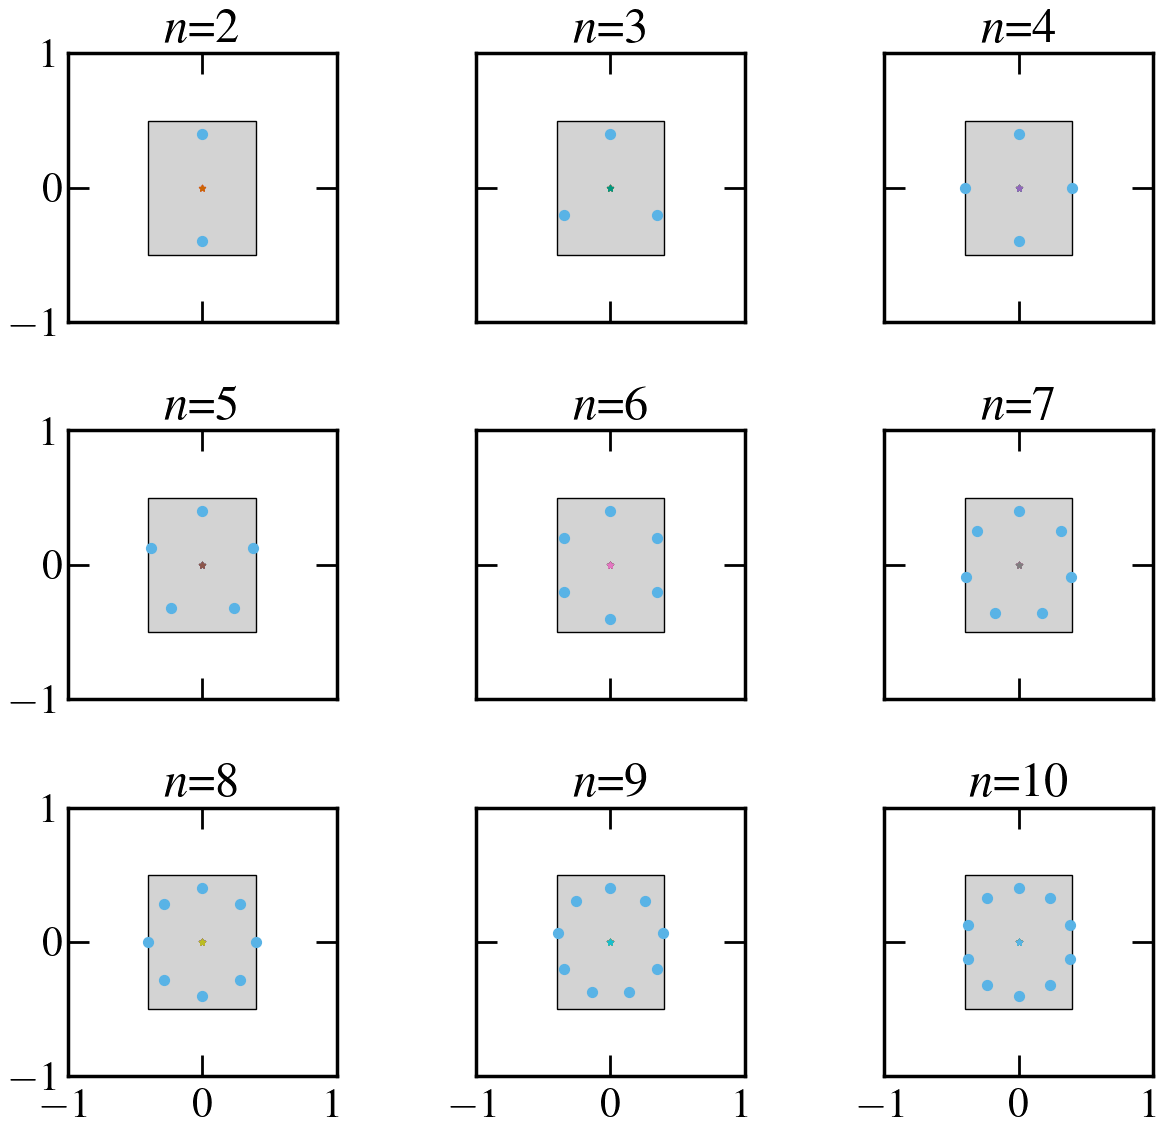

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


class Payload:
    def __init__(self):
        self.params = {"payload_dims": {"x": 0.8, "y": 1, "z": 0.2}}


def quads_config(pyld, n, radius):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    rhos_x = radius * np.sin(angles)
    rhos_y = radius * np.cos(angles)
    rhos = np.vstack((rhos_x, rhos_y))
    return {"rhos": rhos}


def plot_quadrotors_2d(n, radius, ax, title, pyld, conf):
    payload_x = pyld.params["payload_dims"]["x"]
    payload_y = pyld.params["payload_dims"]["y"]

    # Define the rectangle representing the payload
    rect = Rectangle(
        (-payload_x / 2, -payload_y / 2),
        payload_x,
        payload_y,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=1,
        zorder=1,
    )
    ax.add_patch(rect)

    # Plot the quadrotors
    ax.scatter(
        conf["rhos"][0],
        conf["rhos"][1],
        s=50,
        label="Quadrotors",
        zorder=2,
    )

    # Draw lines from quadrotors to payload center
    for x, y in zip(conf["rhos"][0], conf["rhos"][1]):
        ax.scatter([0, 0], [0, 0], s=20, marker="*", label="center", zorder=2)

    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.set_title(f"{title}")


# Main code
pyld = Payload()
n_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

radius = 0.4

fig, axes = plt.subplots(3, 3, sharex=True, sharey=True)

for ax, n in zip(axes.flat, n_values):
    conf = quads_config(pyld, n, radius)
    plot_quadrotors_2d(n, radius, ax, f"$n$={n}", pyld, conf)

plt.tight_layout()
fig.savefig("../figures/quads_2D.pdf", format="pdf", dpi=300)
plt.show()

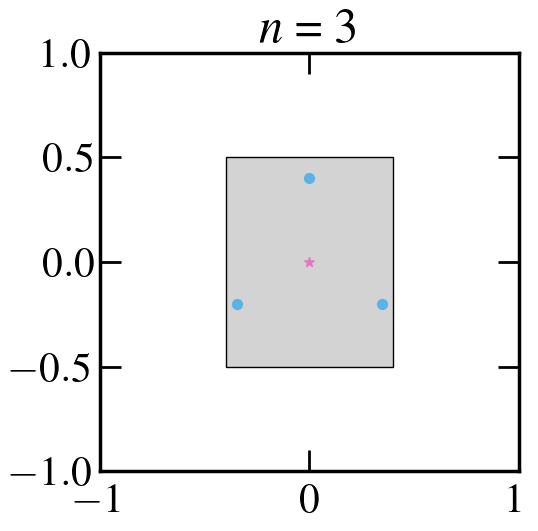

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


class Payload:
    def __init__(self):
        self.params = {"payload_dims": {"x": 0.8, "y": 1, "z": 0.2}}


def quads_config(pyld, n, radius):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    rhos_x = radius * np.sin(angles)
    rhos_y = radius * np.cos(angles)
    rhos = np.vstack((rhos_x, rhos_y))
    return {"rhos": rhos}


def plot_quadrotors_2d(n, radius, ax, title, pyld, conf):
    payload_x = pyld.params["payload_dims"]["x"]
    payload_y = pyld.params["payload_dims"]["y"]

    # Define the rectangle representing the payload
    rect = Rectangle(
        (-payload_x / 2, -payload_y / 2),
        payload_x,
        payload_y,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=1,
        zorder=1,
    )
    ax.add_patch(rect)

    # Plot the quadrotors
    ax.scatter(
        conf["rhos"][0],
        conf["rhos"][1],
        s=50,
        label="Quadrotors",
        zorder=2,
    )

    # Plot the payload center
    ax.scatter([0], [0], s=50, marker="*", label="Center", zorder=4)

    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.set_title(f"{title}")


# Main code
pyld = Payload()
n = 3
radius = 0.4

fig, ax = plt.subplots(figsize=(6, 6))

conf = quads_config(pyld, n, radius)
plot_quadrotors_2d(n, radius, ax, f"$n$ = {n}", pyld, conf)

plt.tight_layout()
fig.savefig("../figures/quads_2D_n3.pdf", format="pdf", dpi=300)
plt.show()

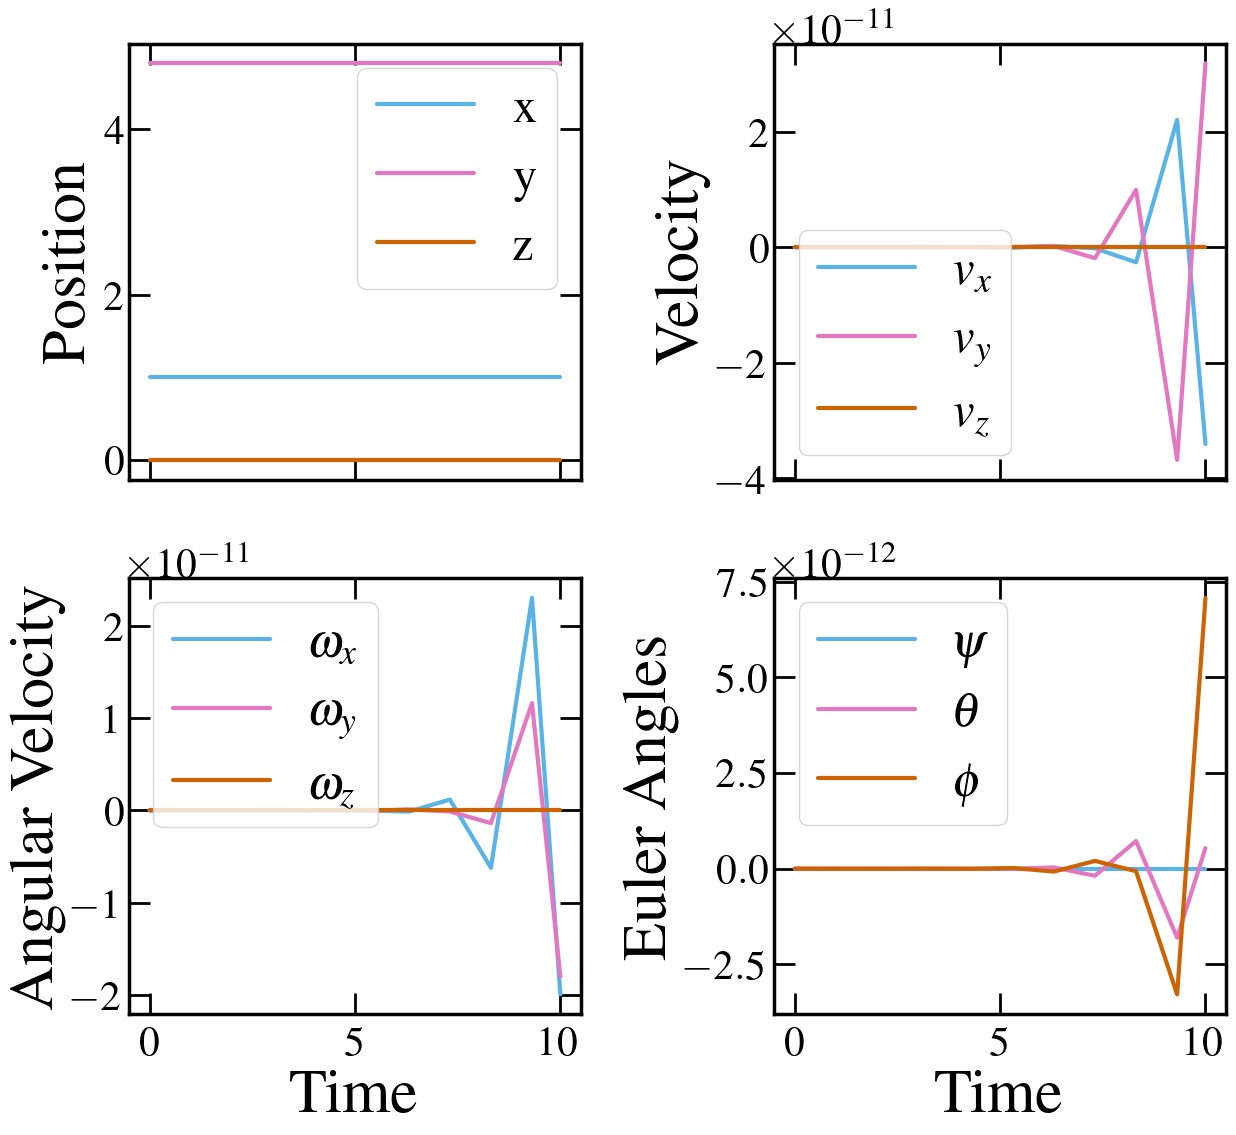

In [4]:
import scipy.io

mat_data = scipy.io.loadmat("states.mat")

states = mat_data["states_struct"]

t = states["t"][0, 0].squeeze()
x0 = states["x0"][0, 0]
v0 = states["v0"][0, 0]
omega0 = states["omega0"][0, 0]
eulers0 = states["eulers0"][0, 0]

fig, axs = plt.subplots(2, 2, sharex=True)

axs[0, 0].plot(t, x0[:, 0], label="x")
axs[0, 0].plot(t, x0[:, 1], label="y")
axs[0, 0].plot(t, -x0[:, 2], label="z")
axs[0, 0].set_ylabel("Position")
axs[0, 0].legend(loc="best")

axs[0, 1].plot(t, v0[:, 0], label="$v_{x}$")
axs[0, 1].plot(t, v0[:, 1], label="$v_{y}$")
axs[0, 1].plot(t, -v0[:, 2], label="$v_{z}$")
axs[0, 1].set_ylabel("Velocity")
axs[0, 1].legend(loc="lower left")

axs[1, 0].plot(t, omega0[:, 0], label="${\omega}_{x}$")
axs[1, 0].plot(t, omega0[:, 1], label="${\omega}_{y}$")
axs[1, 0].plot(t, -omega0[:, 2], label="${\omega}_{z}$")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("Angular Velocity")
axs[1, 0].legend(loc="upper left")

axs[1, 1].plot(t, eulers0[0, :], label="${\psi}$")
axs[1, 1].plot(t, eulers0[1, :], label="$\\theta$")
axs[1, 1].plot(t, -eulers0[2, :], label="${\phi}$")
axs[1, 1].set_xlabel("Time")
axs[1, 1].set_ylabel("Euler Angles")
axs[1, 1].legend(loc="best")

plt.tight_layout()
fig.savefig("../figures/states.pdf", format="pdf", dpi=300)

plt.show()

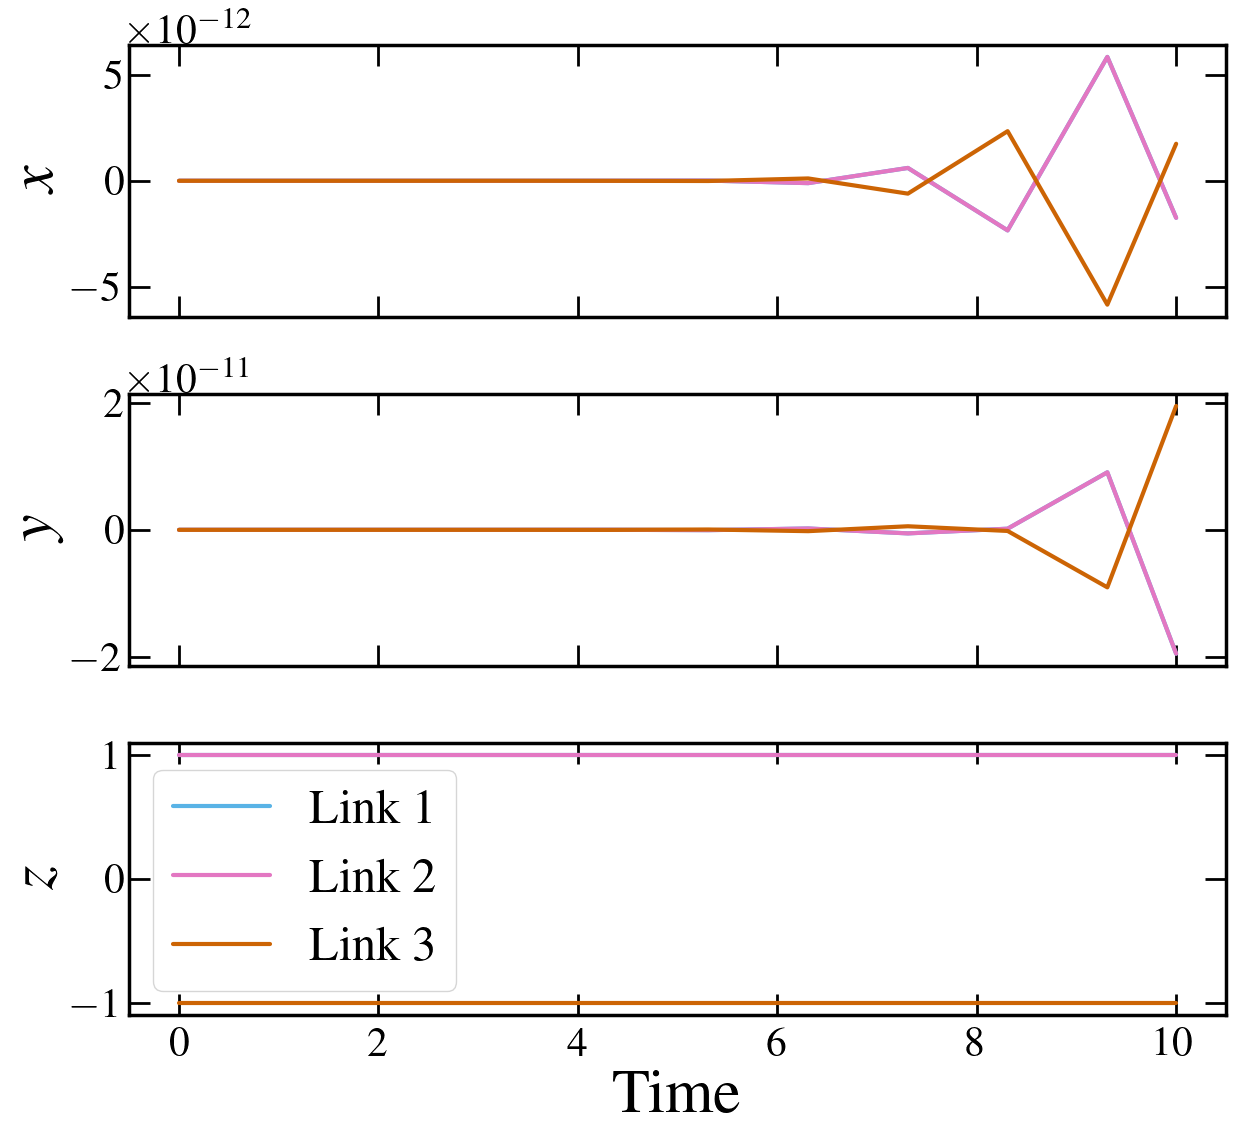

In [5]:
t = states["t"][0, 0].squeeze()
q = states["q"][0, 0]

fig, axs = plt.subplots(3, 1, sharex=True)

axs[0].plot(t, np.squeeze(q[0, 0, :]), label="Link 1")
axs[0].plot(t, np.squeeze(q[0, 1, :]), label="Link 2")
axs[0].plot(t, -np.squeeze(q[0, 2, :]), label="Link 3")
axs[0].set_ylabel("$x$")

axs[1].plot(t, np.squeeze(q[1, 0, :]), label="Link 1")
axs[1].plot(t, np.squeeze(q[1, 1, :]), label="Link 2")
axs[1].plot(t, -np.squeeze(q[1, 2, :]), label="Link 3")
axs[1].set_ylabel("$y$")

axs[2].plot(t, np.squeeze(q[2, 0, :]), label="Link 1")
axs[2].plot(t, np.squeeze(q[2, 1, :]), label="Link 2")
axs[2].plot(t, -np.squeeze(q[2, 2, :]), label="Link 3")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("$z$")
axs[2].legend(loc="lower left")

plt.tight_layout()
fig.savefig("../figures/link orientation.pdf", format="pdf", dpi=300)

plt.show()

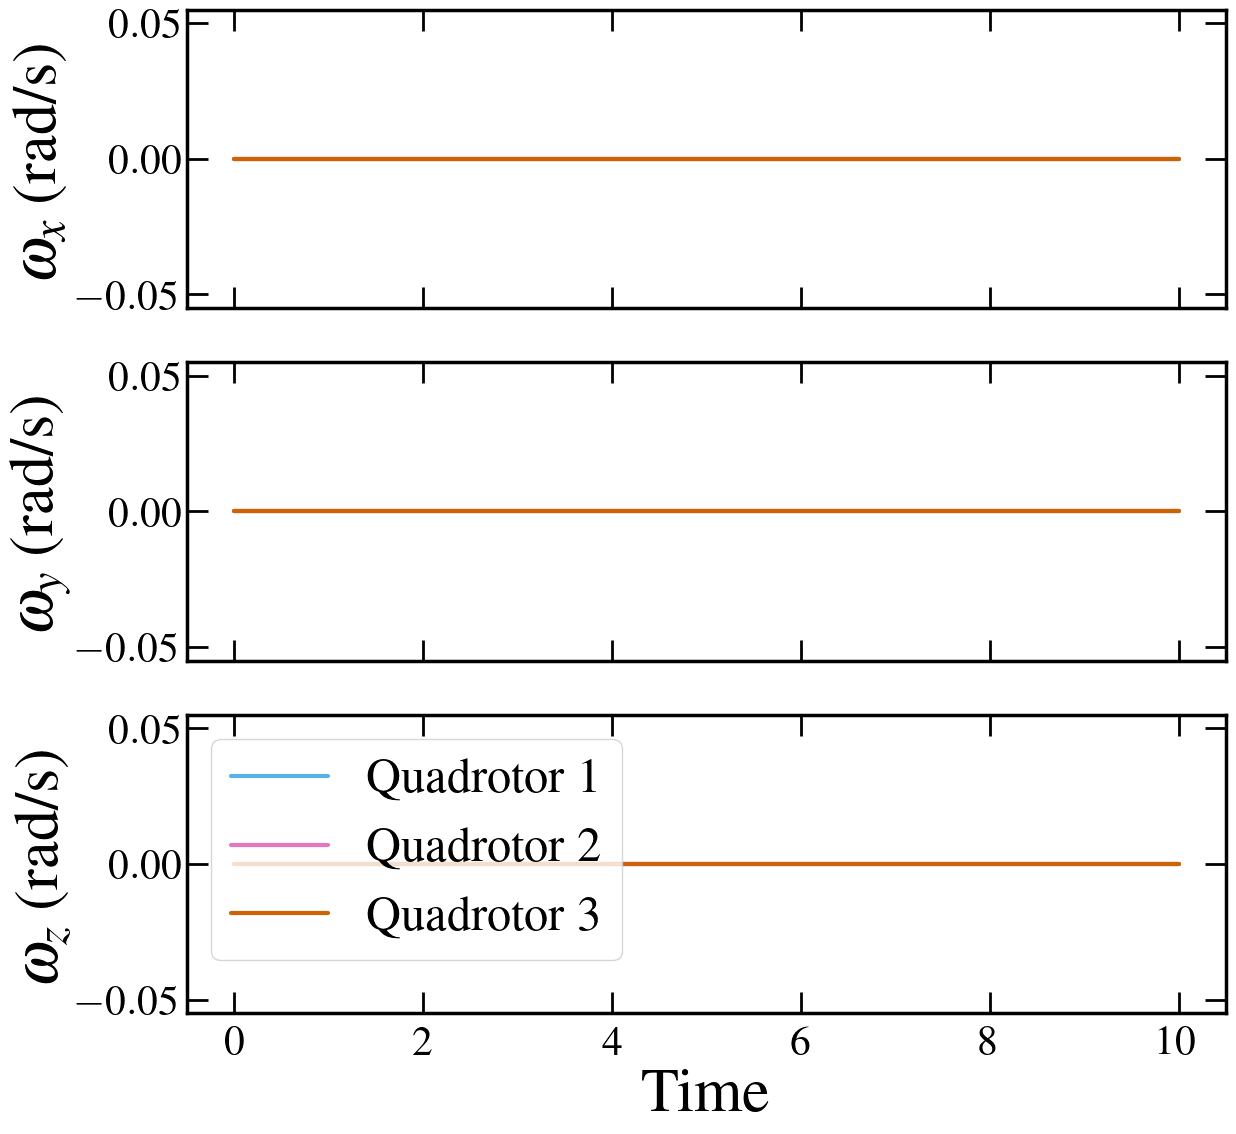

In [6]:
# Extract time and omega data
t = states["t"][0, 0].squeeze()  # Time array
omega = states["omega"][0, 0]

# Create a figure with 3 subplots stacked vertically, sharing the x-axis
fig, axs = plt.subplots(
    3,
    1,
    sharex=True,
)

# Plot Quadrotor Angular Velocity (x)
axs[0].plot(t, np.squeeze(omega[0, 0, :]), label="Quadrotor 1")
axs[0].plot(t, np.squeeze(omega[0, 1, :]), label="Quadrotor 2")
axs[0].plot(t, np.squeeze(omega[0, 2, :]), label="Quadrotor 3")
axs[0].set_ylabel("$\omega_x$ (rad/s)")

# Plot Quadrotor Angular Velocity (y)
axs[1].plot(t, np.squeeze(omega[1, 0, :]), label="Quadrotor 1")
axs[1].plot(t, np.squeeze(omega[1, 1, :]), label="Quadrotor 2")
axs[1].plot(t, np.squeeze(omega[1, 2, :]), label="Quadrotor 3")
axs[1].set_ylabel("$\omega_y$ (rad/s)")

# Plot Quadrotor Angular Velocity (z)
axs[2].plot(t, np.squeeze(omega[2, 0, :]), label="Quadrotor 1")
axs[2].plot(t, np.squeeze(omega[2, 1, :]), label="Quadrotor 2")
axs[2].plot(t, np.squeeze(omega[2, 2, :]), label="Quadrotor 3")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("$\omega_z$ (rad/s)")
axs[2].legend(loc="upper left")

# Apply tight layout to avoid overlap
plt.tight_layout()
fig.savefig("../figures/quad_ang_vel.pdf", format="pdf", dpi=300)

# Show the plot
plt.show()

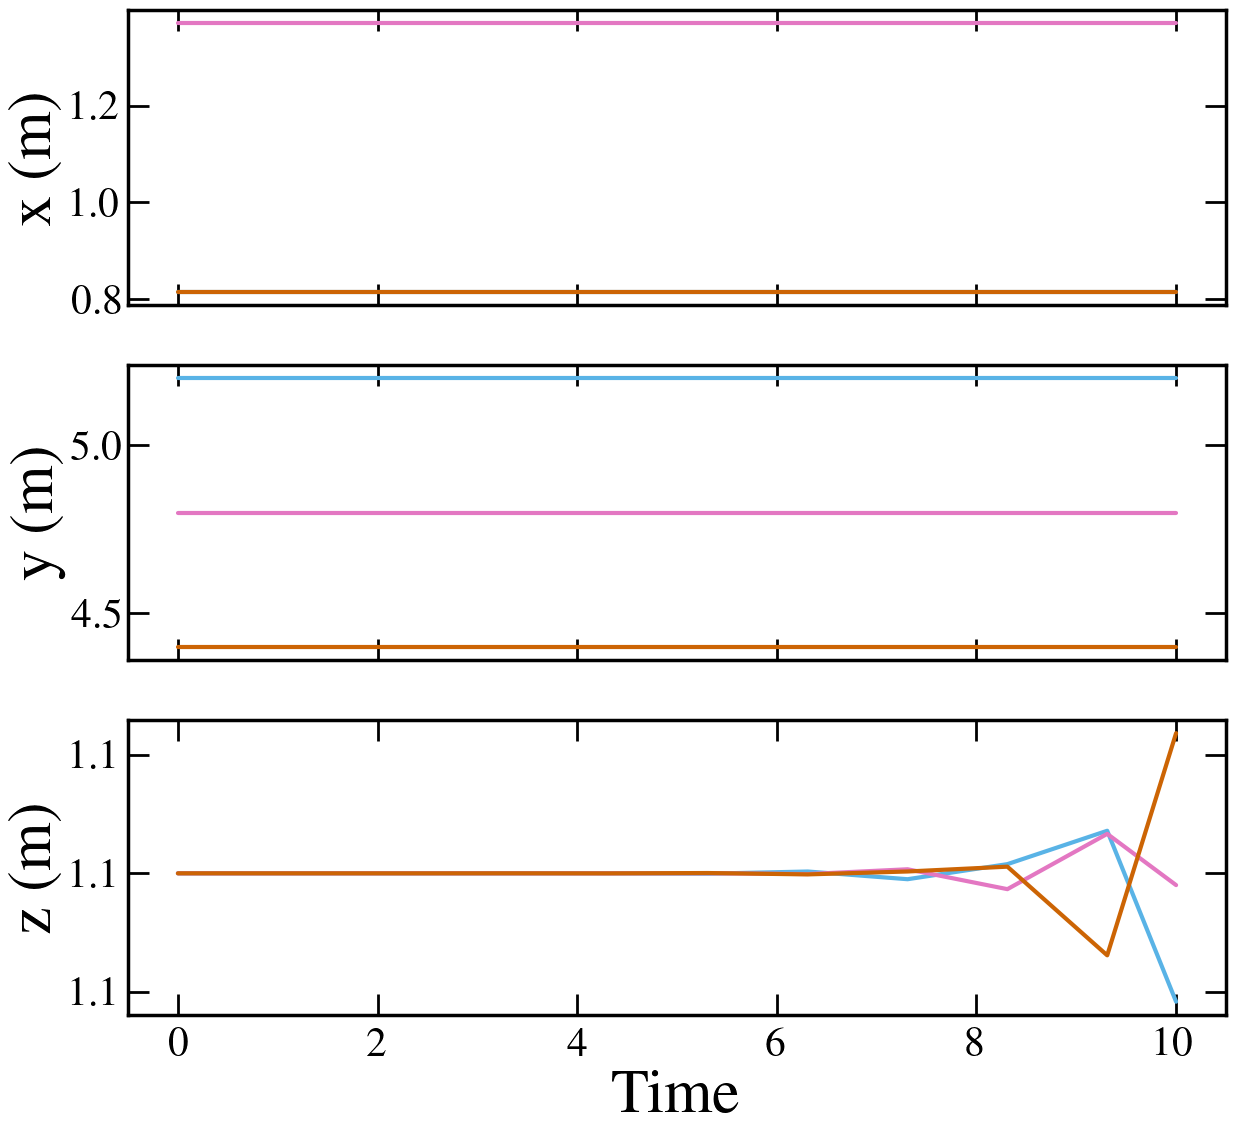

In [7]:
# Extract time and position (x) data
t = states["t"][0, 0].squeeze()  # Time array
# x is a 3D array (assuming it's in the form [3, N, ...])
x = states["x"][0, 0]

# Create a figure with 3 subplots stacked vertically, sharing the x-axis
fig, axs = plt.subplots(3, 1, sharex=True)

# Plot Quadrotor Position (x)
axs[0].plot(t, np.squeeze(x[0, 0, :]), label="Quadrotor 1")
axs[0].plot(t, np.squeeze(x[0, 1, :]), label="Quadrotor 2")
axs[0].plot(t, np.squeeze(x[0, 2, :]), label="Quadrotor 3")
axs[0].set_ylabel("x (m)")
axs[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f"{val:.1f}"))

# Plot Quadrotor Position (y)
axs[1].plot(t, np.squeeze(x[1, 0, :]), label="Quadrotor 1")
axs[1].plot(t, np.squeeze(x[1, 1, :]), label="Quadrotor 2")
axs[1].plot(t, np.squeeze(x[1, 2, :]), label="Quadrotor 3")
axs[1].set_ylabel("y (m)")
axs[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f"{val:.1f}"))

# Plot Quadrotor Position (z)
axs[2].plot(t, -np.squeeze(x[2, 0, :]), label="Quadrotor 1")
axs[2].plot(t, -np.squeeze(x[2, 1, :]), label="Quadrotor 2")
axs[2].plot(t, -np.squeeze(x[2, 2, :]), label="Quadrotor 3")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("z (m)")
axs[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f"{val:.1f}"))

# Apply tight layout to avoid overlap
plt.tight_layout()

fig.savefig("../figures/quad_pos.pdf", format="pdf", dpi=300)

# Show the plot
plt.show()

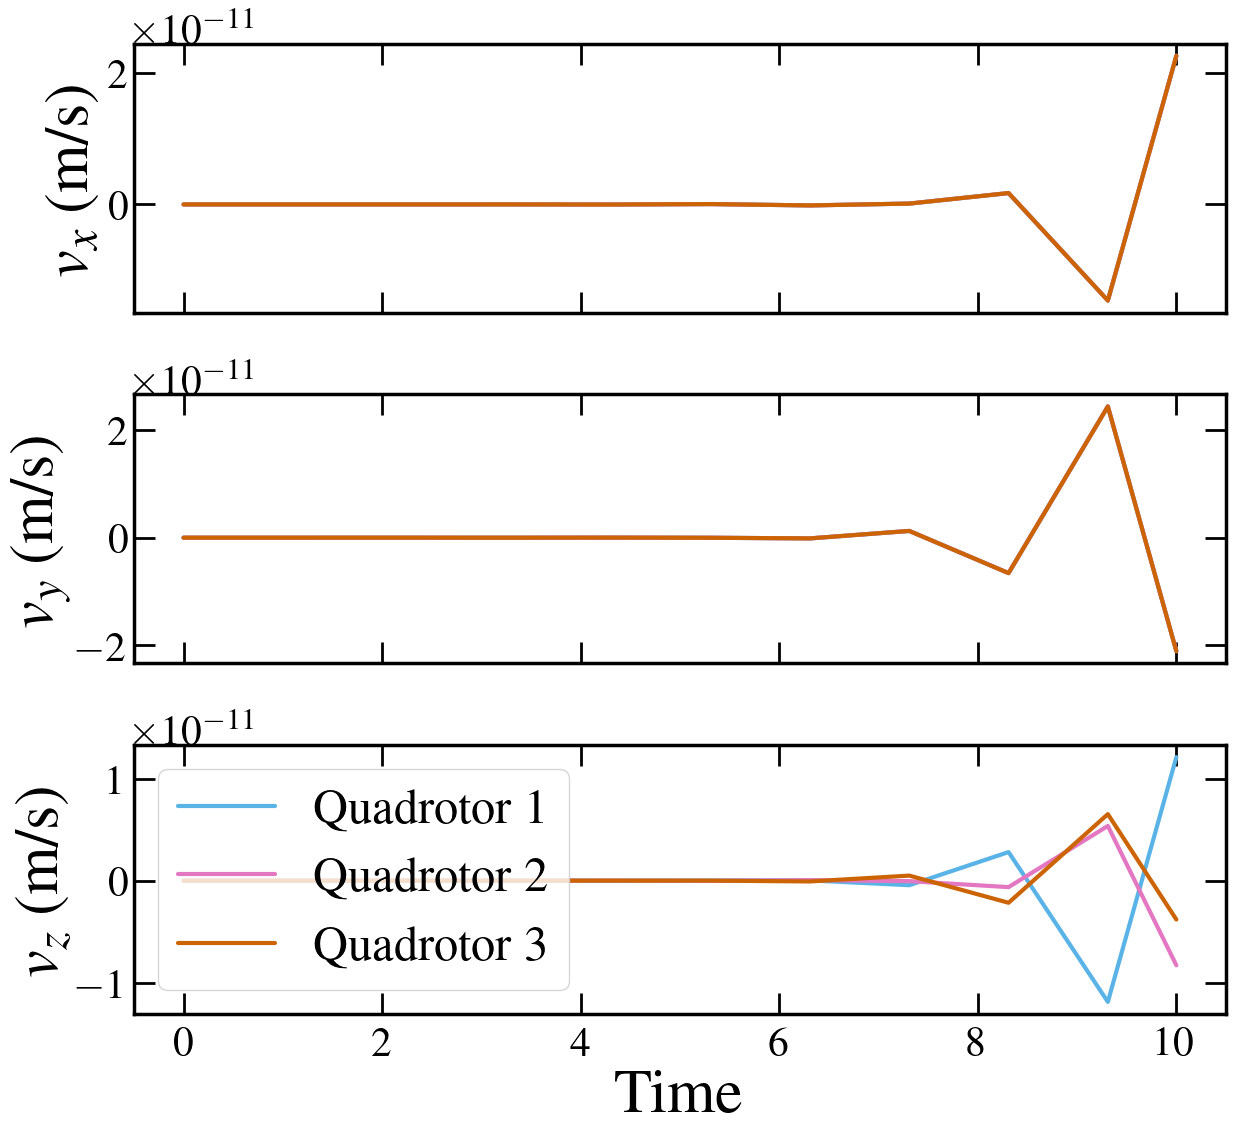

In [8]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# Load the .mat file
mat_data = scipy.io.loadmat("states.mat")

# Assuming the data is stored in a structure, access it like this:
states = mat_data["states_struct"]

# Extract velocity data
v_data = states["v"][0, 0]  # Velocity data (shape is 3 x 3 x 14)
# v_data = v_data.T

# Extract the correct time array
# The number of time steps in v_data is 14, so the time array should have the same length
# Generate a time array matching the number of time steps (14)
t = states["t"][0, 0][0]

# Create a figure with 3 subplots stacked vertically, sharing the x-axis
fig, axs = plt.subplots(3, 1, sharex=True)

# Plot Quadrotor Velocity in x-direction for all quadrotors
axs[0].plot(t, v_data[0, 0, :], label="Quadrotor 1")
axs[0].plot(t, v_data[0, 1, :], label="Quadrotor 2")
axs[0].plot(t, v_data[0, 2, :], label="Quadrotor 3")
axs[0].set_ylabel("$v_x$ (m/s)")

# Plot Quadrotor Velocity in y-direction for all quadrotors
axs[1].plot(t, v_data[1, 0, :], label="Quadrotor 1")
axs[1].plot(t, v_data[1, 1, :], label="Quadrotor 2")
axs[1].plot(t, v_data[1, 2, :], label="Quadrotor 3")
axs[1].set_ylabel("$v_y$ (m/s)")

# Plot Quadrotor Velocity in z-direction for all quadrotors
axs[2].plot(t, v_data[2, 0, :], label="Quadrotor 1")
axs[2].plot(t, v_data[2, 1, :], label="Quadrotor 2")
axs[2].plot(t, v_data[2, 2, :], label="Quadrotor 3")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("$v_z$ (m/s)")
axs[2].legend(loc="upper left")


# Apply tight layout to avoid overlap
# Apply tight layout to avoid overlap
plt.tight_layout()

fig.savefig("../figures/quad_vel.pdf", format="pdf", dpi=300)

# Show the plot
plt.show()